# Step 1: Install Required Library

## We use yfinance to download stock market data.

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



# Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Step 3: Download Stock Data

In [3]:
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
# We will use Apple stock (AAPL)

[*********************100%***********************]  1 of 1 completed


# Step 4: Exploratory Data Analysis(EDA)

In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214888,24.682220,23.776348,24.671145,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534933,23.794069,23.173912,23.596948,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


In [6]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-12-22,191.609467,193.400854,190.985939,193.173208,37149600
2023-12-26,191.065109,191.896469,190.847370,191.619349,28919300
2023-12-27,191.164078,191.510485,189.125261,190.510875,48087700
2023-12-28,191.589676,192.658574,191.183888,192.143916,34049900
2023-12-29,190.550461,192.401229,189.758683,191.906370,42672100


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2015-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2264 non-null   float64
 1   (High, AAPL)    2264 non-null   float64
 2   (Low, AAPL)     2264 non-null   float64
 3   (Open, AAPL)    2264 non-null   float64
 4   (Volume, AAPL)  2264 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 106.1 KB


In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2264.000000,2264.000000,2264.000000,2264.000000,2.264000e+03
mean,81.318619,82.142376,80.412963,81.250262,1.237614e+08
std,55.938537,56.511319,55.304136,55.883934,6.818417e+07
min,20.584818,20.887870,20.386581,20.507345,2.404830e+07
25%,32.784021,32.980019,32.603054,32.796162,7.831732e+07
50%,51.172960,51.983518,50.799039,51.319688,1.056556e+08
75%,138.887657,140.572310,136.389123,138.829244,1.486811e+08
max,196.073090,197.567559,194.974519,195.984019,6.488252e+08


In [9]:
df.isnull().sum() # Checking missing values

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

## Close Price

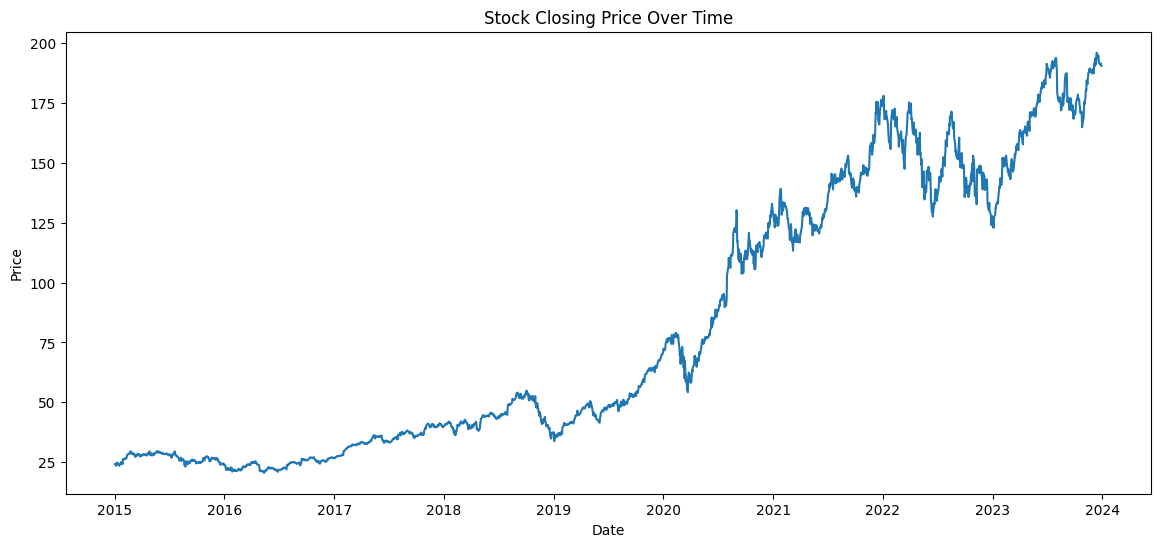

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'])

plt.title("Stock Closing Price Over Time")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

## Open vs Close Price

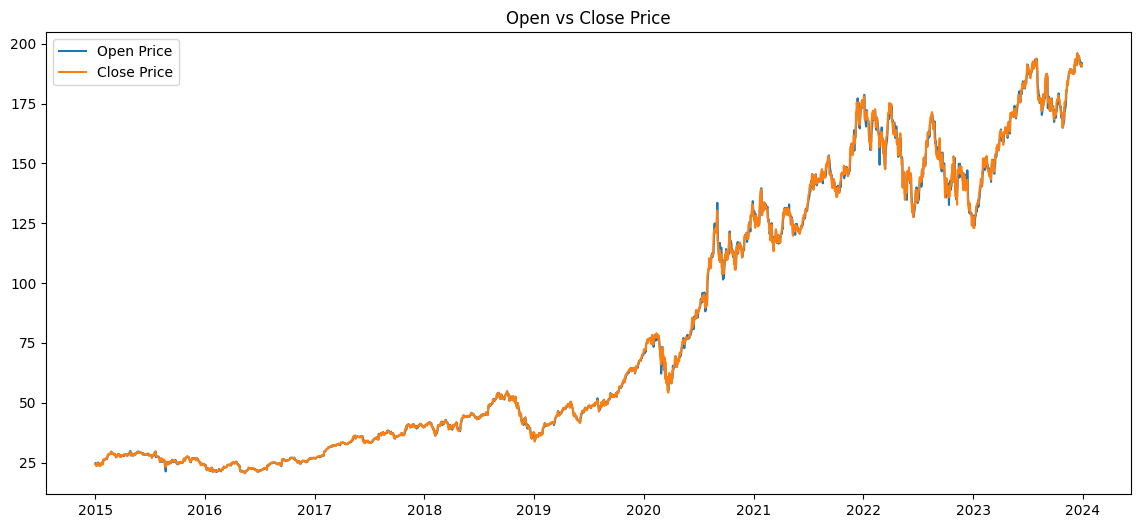

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df['Open'], label="Open Price")

plt.plot(df['Close'], label="Close Price")

plt.legend()

plt.title("Open vs Close Price")

plt.show()

## Daily Return Analysis

In [12]:
df['Daily Return'] = df['Close'].pct_change()

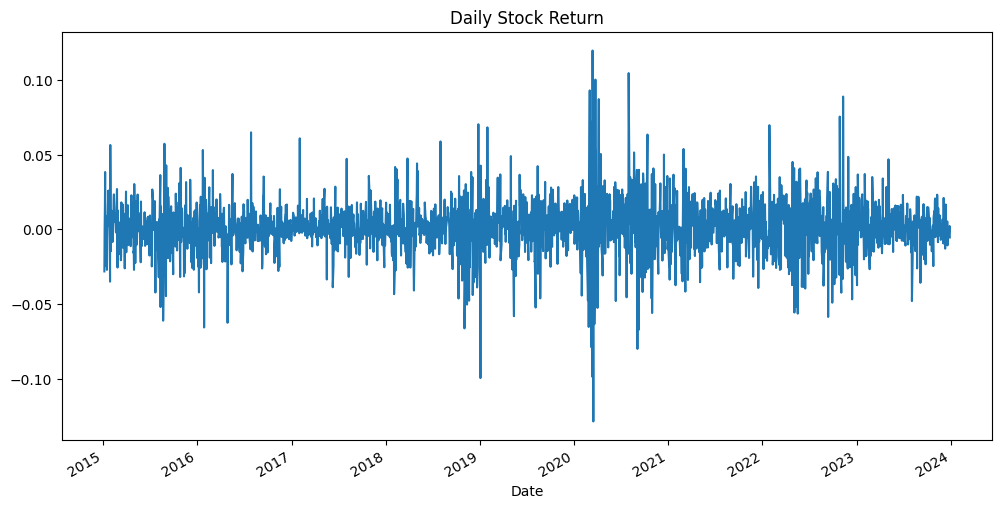

In [13]:
plt.figure(figsize=(12,6))

df['Daily Return'].plot()

plt.title("Daily Stock Return")

plt.show()
# Daily returns help understand volatility.

## Distribution of Returns

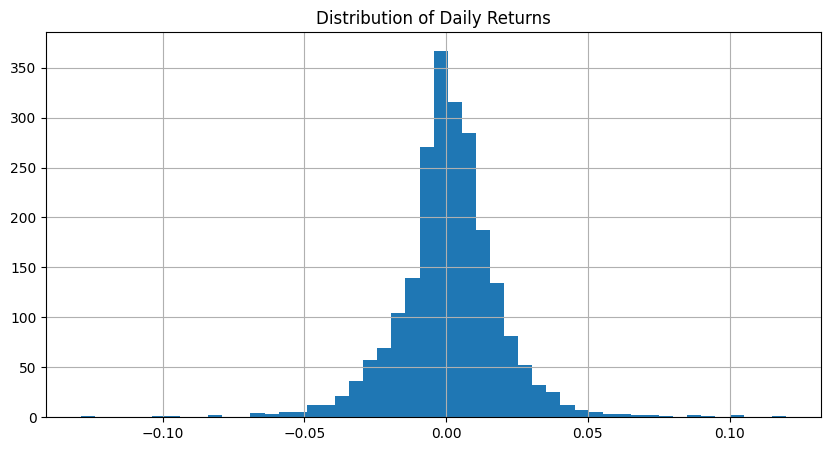

In [14]:
plt.figure(figsize=(10,5))

df['Daily Return'].hist(bins=50)

plt.title("Distribution of Daily Returns")

plt.show()

## Moving Averages

In [16]:
df['MA50'] = df['Close'].rolling(window=50).mean() # df['MA50'] = df['Close'].rolling(window=50).mean()

In [17]:
df['MA200'] = df['Close'].rolling(window=200).mean() #200 Day Moving Average

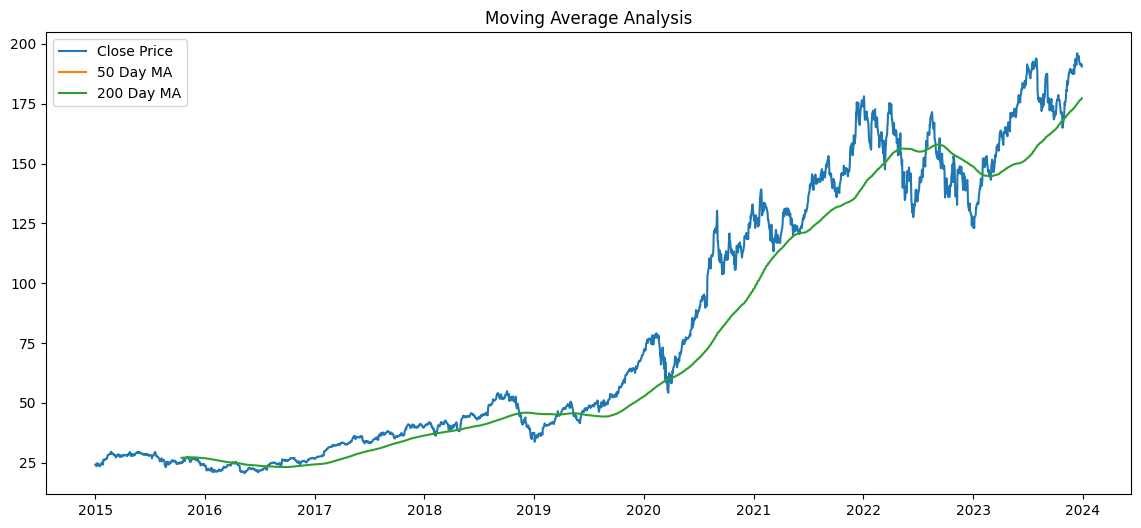

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label="Close Price")

plt.plot(df['MA50'], label="50 Day MA")

plt.plot(df['MA200'], label="200 Day MA")

plt.legend()

plt.title("Moving Average Analysis")

plt.show()
#This helps detect long-term trends.

## Trading Volume Analysis

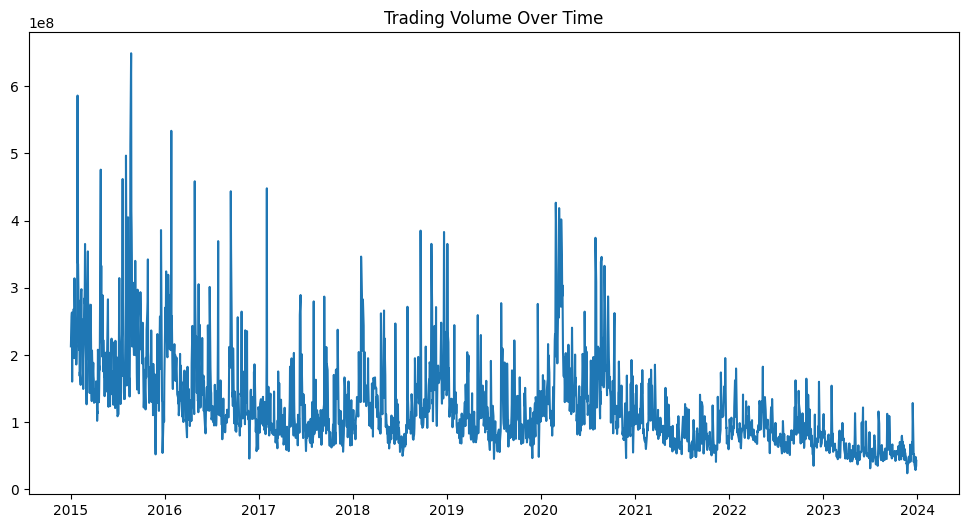

In [20]:
plt.figure(figsize=(12,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")

plt.show()
# Volume indicates market activity.

## Correlation Matrix

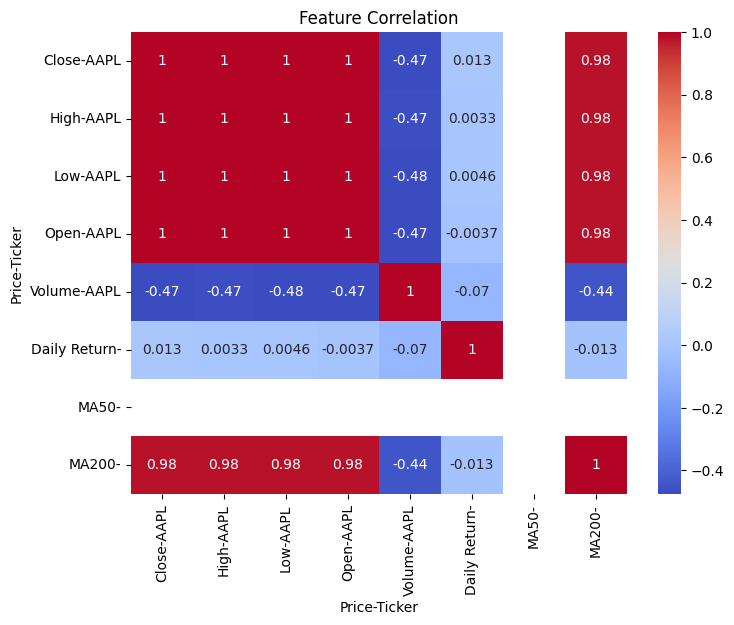

In [21]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()
# This shows relationships between: Open, High, Low, Close, Volume

# Step 5: Visualize Stock Price

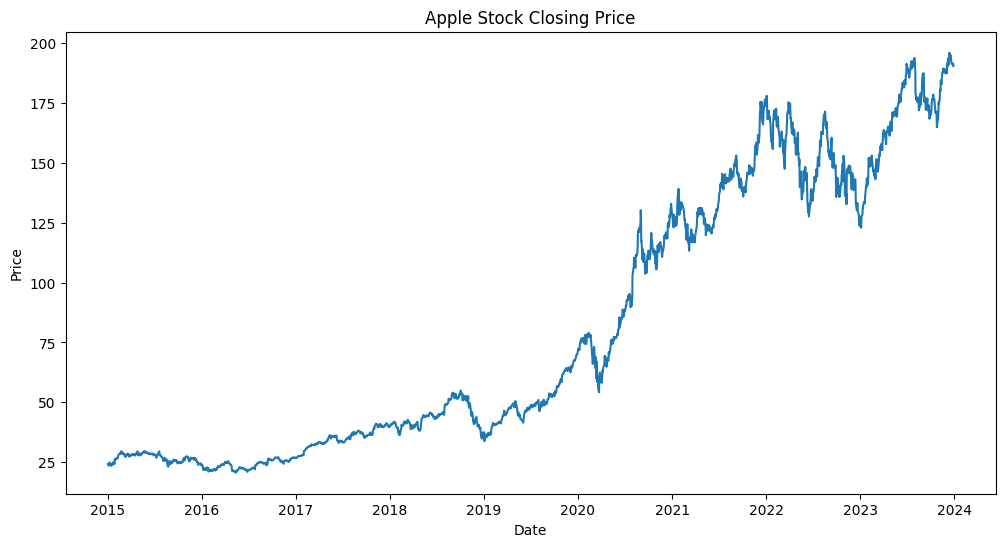

In [22]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

## We will only use Close column.

In [23]:
data = df[["Close"]]

In [25]:
data.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214888
2015-01-05,23.532719
2015-01-06,23.534933
2015-01-07,23.864946
2015-01-08,24.781891


# Step 6: Scaling Data

In [26]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)  #Neural networks perform better when values are scaled.

# Step 7: Creating Time Sequences

## Time series models need previous data points to predict next value.

In [27]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])
    
X = np.array(X)
y = np.array(y)  #We create sequences of 60 days.

In [28]:
X.shape
y.shape

(2204, 1)

# Step 8: Train Test Split

In [29]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [30]:
print(X_train.shape)
print(X_test.shape)

(1763, 60, 1)
(441, 60, 1)


# Step 9: Building LSTM Model

In [31]:
model = Sequential()

In [32]:
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
) #first LSTM layer

C:\Users\sahil\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Adding dropout to prevent overfitting

In [33]:
model.add(Dropout(0.2))

In [34]:
model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
) #Second LSTM layer

In [35]:
model.add(Dropout(0.2)) # another dropout

In [36]:
model.add(Dense(units=1)) # output layer

# Step 10: Compiling Model

In [37]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Step 11: Training Model

In [38]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0093
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0016
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0014
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0014
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0012
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0013
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0013
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0012
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0014
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0011


# Step 12: Predictions

In [39]:
predictions = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


# Step 13: Converting Back to Original Scale

In [40]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test) #We scaled the data earlier.Now reverse scaling.

# Step 14: Plot Predictions

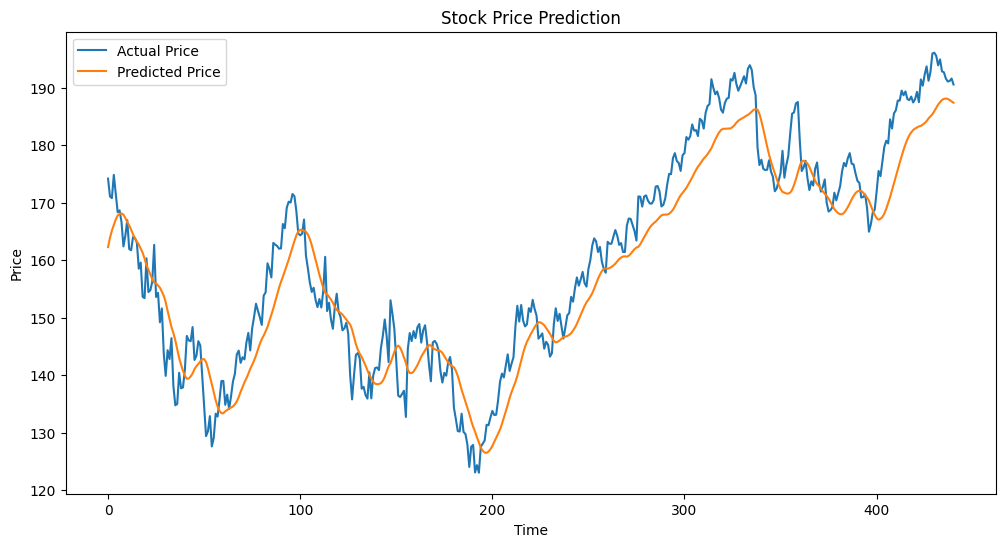

In [41]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")

plt.plot(predictions, label="Predicted Price")

plt.title("Stock Price Prediction")

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()

# Step 15: Model Evaluation

In [42]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("RMSE:", rmse)

RMSE: 6.127826158461823


# Step 16: Save Model

In [43]:
model.save("lstm_stock_model.h5") # model.save("lstm_stock_model.h5")

# Step 17: Predict Future Price

In [44]:
last_60_days = scaled_data[-60:]

last_60_days = np.reshape(last_60_days, (1,60,1))

future_price = model.predict(last_60_days)

future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Price:", future_price)  #Last 60 days to predict next day.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Next Day Predicted Price: [[187.09921]]
